# Deep Fool

## Building and Training the Target Model

In [19]:
import torch
import torch.nn as nn
import os
from typing import Tuple
from htb_ai_library import (
    set_reproducibility,
    MNISTClassifierWithDropout,
    get_mnist_loaders,
    train_model,
    evaluate_accuracy,
    save_model,
    load_model,
    analyze_model_confidence,
    mnist_denormalize,
    HTB_GREEN, NODE_BLACK, HACKER_GREY, WHITE,
    AZURE, NUGGET_YELLOW, MALWARE_RED, VIVID_PURPLE, AQUAMARINE
)

set_reproducibility(1337)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [9]:
# MNISTClassifierWithDropout is imported from htb_ai_library
# The architecture internally defines:
# - Conv1: 1->32 channels, 3x3 kernel, ReLU, 2x2 pooling, 25% dropout
# - Conv2: 32->64 channels, 3x3 kernel, ReLU, 2x2 pooling, 25% dropout
# - FC1: 3136->128, ReLU, 50% dropout
# - FC2: 128->10 (logits)

model = MNISTClassifierWithDropout().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 1,625,866


In [10]:
model_path = 'output/mnist_model.pth'
os.makedirs('output', exist_ok = True)

# try loading cached model
if os.path.exists(model_path):
    print(f"Found cached model at {model_path}")
    model_data = load_model(model_path)
    model = model_data['model'].to(device)
    model.eval()

    # validate cached model
    _, test_loader = get_mnist_loaders(batch_size=100, normalize=True)
    accuracy = evaluate_accuracy(model, test_loader, device)
    print(f"Cached model accuracy: {accuracy:.2f}%")

    if accuracy < 90.0:
        print("Accuracy bellow threshold, retraining required")
        model = None
else:
    model = None

Found cached model at output/mnist_model.pth
Model loaded from output/mnist_model.pth
Cached model accuracy: 99.05%


In [11]:
if model is None:
    print("Training new model...")
    train_loader, test_loader = get_mnist_loaders(batch_size=64,normalize=True)
    model = MNISTClassifierWithDropout().to(device)

    model = train_model(
        model, train_loader, test_loader,
        epochs=5, device=device
    )

In [12]:
# Evaluate and cache
accuracy = evaluate_accuracy(model, test_loader, device)
print(f"Test Accuracy: {accuracy:.2f}%")

save_model({
    'model': model,
    'architecture': 'MNISTClassifierWithDropout',
    'accuracy': accuracy,
    'training_config': {
        'epochs': 5,
        'batch_size': 64,
        'device': str(device)
    }
}, model_path)


Test Accuracy: 99.05%
Model saved to output/mnist_model.pth


In [13]:
# Analyze confidence distribution
_, test_loader = get_mnist_loaders(batch_size=100, normalize=True)
stats = analyze_model_confidence(model, test_loader, device=device, num_samples=1000)


## DeepFool Implementation

In [14]:
def deepfool(image: torch.Tensor,
            net: nn.Module, 
            num_classes: int = 10, # limits search to the top-scoring classes
            overshoot: float = 0.02, # ensures the algorithm crosses the true non-linear boundary
            max_iter: int = 50,
            device: str = 'cuda') -> Tuple[torch.Tensor, int, int, torch.Tensor]:
    
    """
    Generate minimal adversarial perturbation using DeepFool algorithm.

    Args:
        image (torch.Tensor): Input image tensor of shape (1, C, H, W)
        net (nn.Module): Target neural network in evaluation mode
        num_classes (int): Number of top-scoring classes to consider (default: 10)
        overshoot (float): Overshoot parameter for boundary crossing (default: 0.02)
        max_iter (int): Maximum iterations before terminating (default: 50)
        device (str): Computation device ('cuda' or 'cpu')

    Returns:
        Tuple containing:
            - r_tot (torch.Tensor): Total accumulated perturbation
            - loop_i (int): Number of iterations performed
            - label (int): Original predicted class
            - k_i (int): Final adversarial class
            - pert_image (torch.Tensor): Final perturbed image
    """
    image = image.to(device)
    net = net.to(device)

    # original prediction and class ordering (descending score)
    f_image = net(image).data.cpu().numpy().flatten()
    I = f_image.argsort()[::-1]
    label = I[0]

    # Working tensors and accumulators
    input_shape = image.shape
    pert_image = image.clone()
    r_tot = torch.zeros(input_shape).to(device)
    loop_i = 0

    # iterate until a successful perturbation is found or the limit is reached
    while loop_i < max_iter:
        x = pert_image.clone().requires_grad_(True)
        fs = net(x)

        # current top prediciton at x
        k_i = fs.data.cpu().numpy().flatten().argsort()[::-1][0]

        # current top prediction changes
        if k_i != label:
            break

        # initialize the best candidate step for this iteration
        pert = float('inf')
        w = None
    
        # search minimal step among candidate classes
        for k in range(1, num_classes):
            if I[k] == label:
                continue
        
        # comput the gradient for candidate class
        if x.grad is not None:
            x.grad.zero_()
        fs[0, I[k]].backward(retain_graph = True)
        grad_k = x.grad.data.clone()

        # compute gradient for the original class
        if x.grad is not None:
            x.grad.zero_()
        
        fs[0, label].backward(retain_graph=True)
        grad_label = x.grad.data.clone()

        # direction adn distance under liniearization
        w_k = grad_k - grad_label
        f_k = (fs[0, I[k]]-fs[0, label]).data.cpu().numpy()
        pert_k = abs(f_k) / (torch.norm(w_k.flatten())) + 1e-10

        if pert_k < pert:
            pert = pert_k
            w = w_k
        
        # Minimal step for the selected direction
        r_i = (pert + 1e-4) * w / (torch.norm(w.flatten()) + 1e-10)
        r_tot = r_tot + r_i

        # apply with overshoot to ensure crossing
        pert_image = image + (1+overshoot) * r_tot
        loop_i += 1
    
    return r_tot, loop_i, label, k_i, pert_image


## Demonstrating DeepFool

In [15]:
# Load trained model
model_path = 'output/mnist_model.pth'
if os.path.exists(model_path):
    model_data = load_model(model_path)
    model = model_data['model'].to(device)
    model.eval()
else:
    raise FileNotFoundError("Model not found.")

# Get single test sample
_, test_loader = get_mnist_loaders(batch_size=1, normalize=True)
dataiter = iter(test_loader)
image, true_label = next(dataiter)
image = image.to(device)

print(f"True label: {true_label.item()}")

Model loaded from output/mnist_model.pth
True label: 7


In [16]:
import torch.nn.functional as F
# Baseline classification
with torch.no_grad():
    original_output = model(image)
    original_pred = original_output.argmax(dim=1).item()
    original_confidence = F.softmax(original_output, dim=1).max().item()

print(f"Original: class {original_pred} (confidence: {original_confidence:.3f})")

# Execute DeepFool attack
r_total, iterations, orig_label, pert_label, pert_image = deepfool(
    image, model, num_classes=10, overshoot=0.02, max_iter=50, device=device
)

print(f"Attack: {orig_label} -> {pert_label} in {iterations} iterations")

Original: class 7 (confidence: 1.000)
Attack: 7 -> 3 in 3 iterations


In [17]:
# Compute perturbation norms
perturbation_norm_l2 = torch.norm(r_total).item()
perturbation_norm_linf = torch.abs(r_total).max().item()
relative_perturbation = perturbation_norm_l2 / torch.norm(image).item()

# Evaluate adversarial confidence
with torch.no_grad():
    adv_output = model(pert_image)
    adv_confidence = F.softmax(adv_output, dim=1).max().item()

# Display results
print(f"\n=== Attack Results ===")
print(f"L2 norm: {perturbation_norm_l2:.4f}")
print(f"L∞ norm: {perturbation_norm_linf:.4f}")
print(f"Relative perturbation: {relative_perturbation:.2%}")
print(f"Original confidence: {original_confidence:.3f}")
print(f"Adversarial confidence: {adv_confidence:.3f}")


=== Attack Results ===
L2 norm: 9.5717
L∞ norm: 2.4025
Relative perturbation: 40.26%
Original confidence: 1.000
Adversarial confidence: 0.213


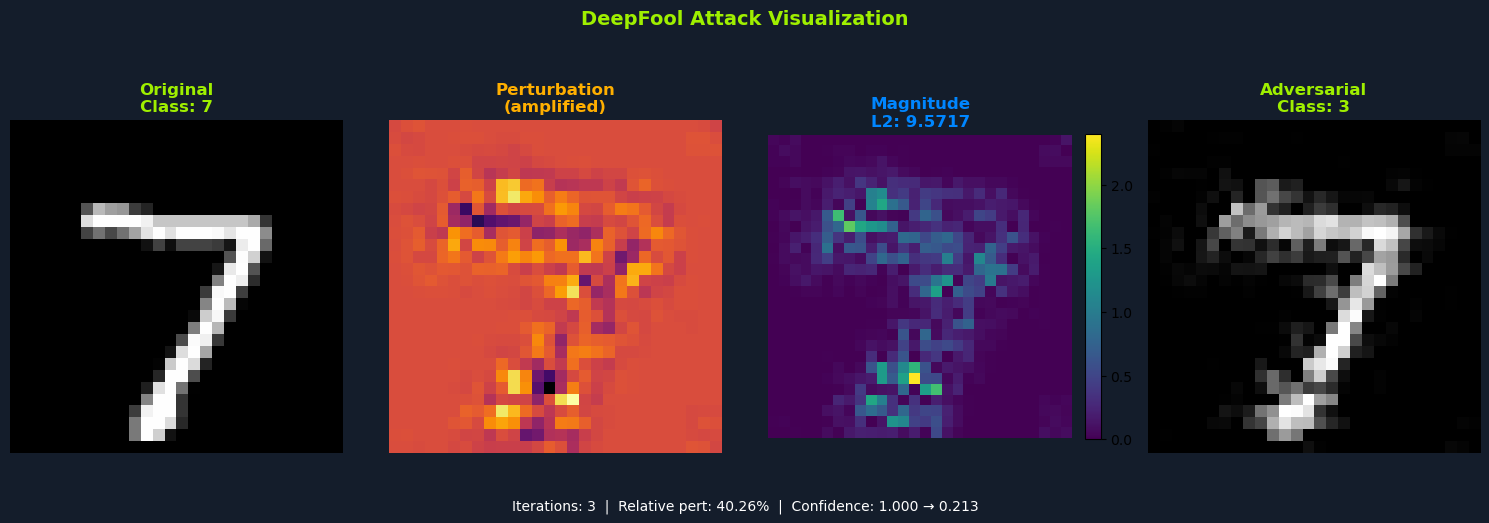

In [22]:
import matplotlib.pyplot as plt
import numpy as np
# Prepare images for visualization
original_img = mnist_denormalize(image.squeeze()).cpu().numpy()
adversarial_img = mnist_denormalize(pert_image.squeeze()).cpu().numpy()
perturbation = r_total.cpu().squeeze().numpy()

# Normalize perturbation for visibility (amplify minimal changes)
pert_display = perturbation - perturbation.min()
if pert_display.max() > 0:
    pert_display = pert_display / pert_display.max()

# Create four-panel visualization
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
fig.patch.set_facecolor(NODE_BLACK)

for ax in axes:
    ax.set_facecolor(NODE_BLACK)
    for spine in ax.spines.values():
        spine.set_edgecolor(HACKER_GREY)

# Panel 1: Original clean image
axes[0].imshow(original_img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f"Original\nClass: {original_pred}",
                  color=HTB_GREEN, fontweight='bold')
axes[0].axis('off')

# Panel 2: Amplified perturbation pattern
axes[1].imshow(pert_display, cmap='inferno')
axes[1].set_title("Perturbation\n(amplified)",
                  color=NUGGET_YELLOW, fontweight='bold')
axes[1].axis('off')

# Panel 3: Perturbation magnitude heatmap
im = axes[2].imshow(np.abs(perturbation), cmap='viridis')
axes[2].set_title(f"Magnitude\nL2: {perturbation_norm_l2:.4f}",
                  color=AZURE, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

# Panel 4: Adversarial result
title_color = HTB_GREEN if pert_label != original_pred else MALWARE_RED
axes[3].imshow(adversarial_img, cmap='gray', vmin=0, vmax=1)
axes[3].set_title(f"Adversarial\nClass: {pert_label}",
                  color=title_color, fontweight='bold')
axes[3].axis('off')

# Summary metrics
metrics_text = (
    f"Iterations: {iterations}  |  "
    f"Relative pert: {relative_perturbation:.2%}  |  "
    f"Confidence: {original_confidence:.3f} → {adv_confidence:.3f}"
)
fig.text(0.5, 0.02, metrics_text, ha='center', fontsize=10, color=WHITE)

plt.suptitle("DeepFool Attack Visualization", fontsize=14,
             color=HTB_GREEN, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



## Batch Attack Generation

In [23]:
num_examples = 20
print(f"\nGenerating {num_examples} adversarial examples using DeepFool...")

_, test_loader = get_mnist_loaders(batch_size=1, normalize=True)
model.eval()

results = []
success_count = 0

print(f"Test loader ready with {len(test_loader.dataset)} samples")
print(f"Will process first {num_examples} samples")
print("Starting batch attack generation...")


Generating 20 adversarial examples using DeepFool...
Test loader ready with 10000 samples
Will process first 20 samples
Starting batch attack generation...


In [24]:
for idx, (data, target) in enumerate(test_loader):
    if idx >= num_examples:
        break

    data = data.to(device)

    # Execute DeepFool attack
    r, iterations, orig_label, adv_label, pert_image = deepfool(
        data, model, num_classes=10, overshoot=0.02, max_iter=50, device=device
    )

    # Track success and store metrics
    success = (orig_label != adv_label)
    if success:
        success_count += 1

    results.append({
        'original_image': data.cpu(),
        'perturbation': r.cpu(),
        'perturbed_image': pert_image.cpu(),
        'original_label': orig_label,
        'adversarial_label': adv_label,
        'iterations': iterations,
        'true_label': target.item(),
        'l2_norm': torch.norm(r.cpu()).item(),
        'success': success
    })

    # Progress feedback
    print(f"  Example {idx+1}: True={target.item()}, Orig={orig_label}, "
          f"Adv={adv_label}, Iter={iterations}, L2={torch.norm(r.cpu()).item():.4f}")

  Example 1: True=7, Orig=7, Adv=3, Iter=3, L2=9.5717
  Example 2: True=2, Orig=2, Adv=6, Iter=3, L2=9.5528
  Example 3: True=1, Orig=1, Adv=7, Iter=1, L2=6.4824
  Example 4: True=0, Orig=0, Adv=3, Iter=3, L2=8.0605
  Example 5: True=4, Orig=4, Adv=9, Iter=2, L2=8.1102
  Example 6: True=1, Orig=1, Adv=8, Iter=2, L2=8.5801
  Example 7: True=4, Orig=4, Adv=8, Iter=1, L2=4.4116
  Example 8: True=9, Orig=9, Adv=4, Iter=2, L2=7.5165
  Example 9: True=5, Orig=5, Adv=6, Iter=1, L2=5.5104
  Example 10: True=9, Orig=9, Adv=8, Iter=1, L2=7.5848
  Example 11: True=0, Orig=0, Adv=2, Iter=2, L2=7.7231
  Example 12: True=6, Orig=6, Adv=3, Iter=2, L2=9.8644
  Example 13: True=9, Orig=9, Adv=8, Iter=2, L2=8.0363
  Example 14: True=0, Orig=0, Adv=9, Iter=2, L2=8.4469
  Example 15: True=1, Orig=1, Adv=8, Iter=2, L2=8.5422
  Example 16: True=5, Orig=5, Adv=8, Iter=2, L2=8.7341
  Example 17: True=9, Orig=9, Adv=4, Iter=1, L2=7.0645
  Example 18: True=7, Orig=7, Adv=0, Iter=3, L2=11.1569
  Example 19: True

In [25]:
print(f"\nAttack Success Rate: {success_count}/{num_examples} "
      f"({100*success_count/num_examples:.1f}%)")
print(f"Average L2 norm: {np.mean([r['l2_norm'] for r in results]):.4f}")
print(f"Average iterations: {np.mean([r['iterations'] for r in results]):.1f}")


Attack Success Rate: 20/20 (100.0%)
Average L2 norm: 7.8228
Average iterations: 1.9



Generating attack grid visualization...


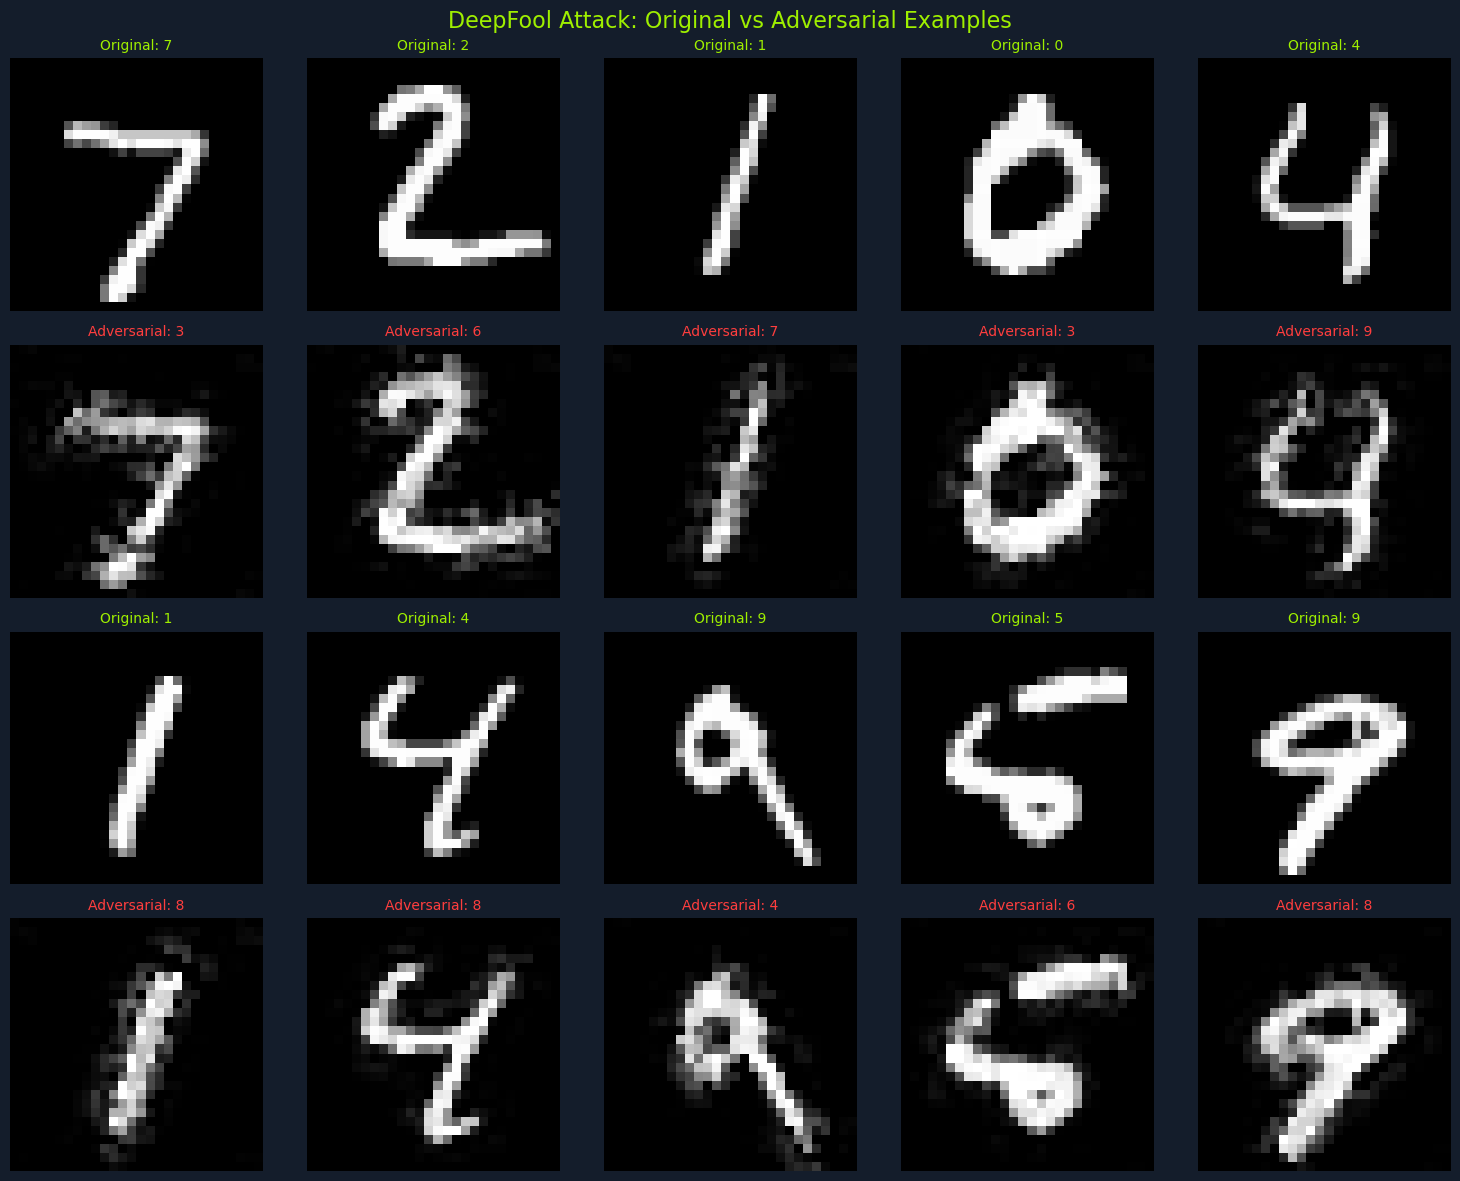

Grid visualization saved to output/deepfool_examples.png


In [27]:
def visualize_attack_grid(results, save_dir='output'):
    """
    Create grid visualization showing original and adversarial images side-by-side.

    Args:
        results (list): Attack results from batch generation
        save_dir (str): Directory to save visualization
    """
    print("\nGenerating attack grid visualization...")

    num_examples = min(10, len(results))
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    fig.patch.set_facecolor(NODE_BLACK)

    for ax in axes.flatten():
        ax.set_facecolor(NODE_BLACK)
        for spine in ax.spines.values():
            spine.set_edgecolor(HACKER_GREY)

    for idx in range(num_examples):
        row = idx // 5
        col = idx % 5

        # Original image (top row for this column)
        ax_original = axes[row * 2, col]
        img = mnist_denormalize(results[idx]['original_image'].squeeze()).numpy()
        ax_original.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax_original.set_title(f"Original: {results[idx]['original_label']}",
                            color=HTB_GREEN, fontsize=10)
        ax_original.axis('off')

        # Adversarial image (bottom row for this column)
        ax_adv = axes[row * 2 + 1, col]
        adv_img = mnist_denormalize(results[idx]['perturbed_image'].squeeze()).numpy()
        ax_adv.imshow(adv_img, cmap='gray', vmin=0, vmax=1)

        title_color = MALWARE_RED if results[idx]['success'] else HACKER_GREY
        ax_adv.set_title(f"Adversarial: {results[idx]['adversarial_label']}",
                        color=title_color, fontsize=10)
        ax_adv.axis('off')

    plt.suptitle('DeepFool Attack: Original vs Adversarial Examples',
                color=HTB_GREEN, fontsize=16, y=0.98)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'deepfool_examples.png'),
                facecolor=NODE_BLACK, dpi=150, bbox_inches='tight')
    plt.show()   # display in notebook before closing
    plt.close()

    print(f"Grid visualization saved to {save_dir}/deepfool_examples.png")

# Generate the grid visualization
visualize_attack_grid(results, save_dir='output')

## Perturbation Analysis and Metics


Generating perturbation analysis...


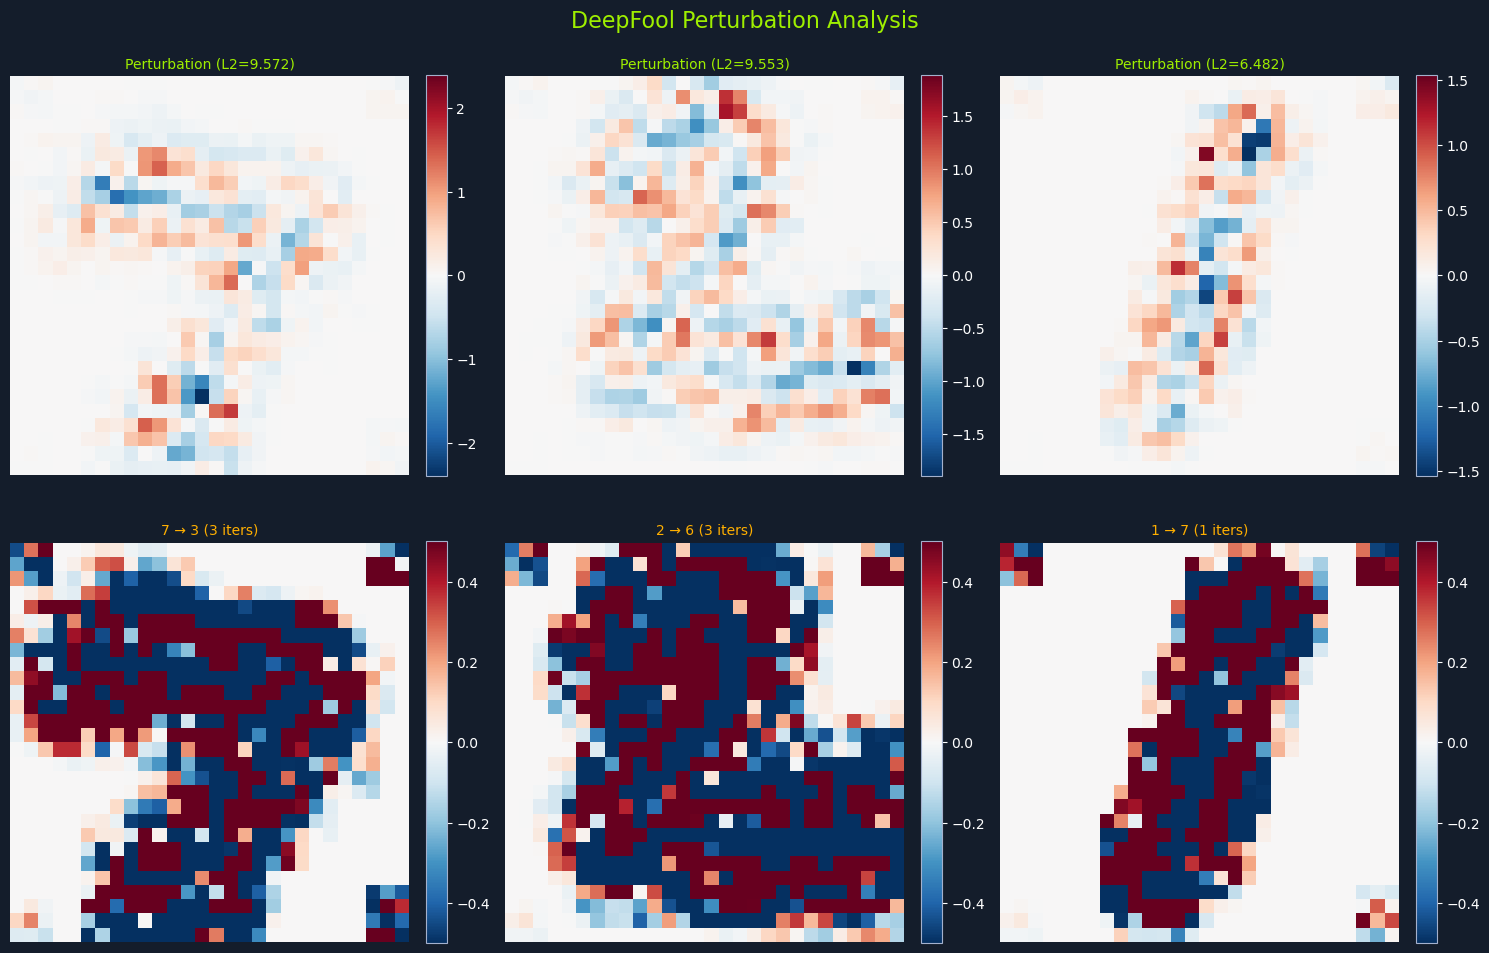

Perturbation analysis saved to output/deepfool_perturbations.png


In [30]:
def visualize_perturbation_analysis(results, save_dir='output'):
    """
    Analyze and visualize perturbation characteristics across samples.

    Creates two-row visualization: top shows raw perturbation heatmaps,
    bottom shows amplified differences overlaid on originals.

    Args:
        results (list): Attack results
        save_dir (str): Output directory
    """
    print("\nGenerating perturbation analysis...")

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.patch.set_facecolor(NODE_BLACK)

    for ax in axes.flatten():
        ax.set_facecolor(NODE_BLACK)
        for spine in ax.spines.values():
            spine.set_edgecolor(HACKER_GREY)

    # Select first 3 successful attacks
    successful_attacks = [r for r in results if r['success']][:3]

    for idx, result in enumerate(successful_attacks):
        # Top row: Raw perturbation heatmap
        ax_top = axes[0, idx]
        pert = result['perturbation'].squeeze().numpy()
        vmax = np.abs(pert).max() or 1e-6
        im_top = ax_top.imshow(pert, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax_top.set_title(f'Perturbation (L2={result["l2_norm"]:.3f})',
                        color=HTB_GREEN, fontsize=10)
        ax_top.axis('off')

        cbar_top = plt.colorbar(im_top, ax=ax_top, fraction=0.046, pad=0.04)
        cbar_top.outline.set_edgecolor(HACKER_GREY)
        cbar_top.ax.tick_params(colors=WHITE)

        # Bottom row: Amplified difference visualization
        ax_bottom = axes[1, idx]
        orig_img = result['original_image'].squeeze().numpy()
        adv_img = result['perturbed_image'].squeeze().detach().numpy()
        diff_amplified = (adv_img - orig_img) * 10  # 10x amplification for visibility

        im_bottom = ax_bottom.imshow(diff_amplified, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
        ax_bottom.set_title(f"{result['original_label']} → {result['adversarial_label']} "
                           f"({result['iterations']} iters)",
                           color=NUGGET_YELLOW, fontsize=10)
        ax_bottom.axis('off')

        cbar_bottom = plt.colorbar(im_bottom, ax=ax_bottom, fraction=0.046, pad=0.04)
        cbar_bottom.outline.set_edgecolor(HACKER_GREY)
        cbar_bottom.ax.tick_params(colors=WHITE)

    plt.suptitle('DeepFool Perturbation Analysis', color=HTB_GREEN, fontsize=16, y=0.98)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'deepfool_perturbations.png'),
                facecolor=NODE_BLACK, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"Perturbation analysis saved to {save_dir}/deepfool_perturbations.png")

# Generate the perturbation analysis visualization
visualize_perturbation_analysis(results, save_dir='output')


Generating attack metrics visualization...
L2 norm range: [3.4764, 11.1569]
Iteration range: [1, 3]


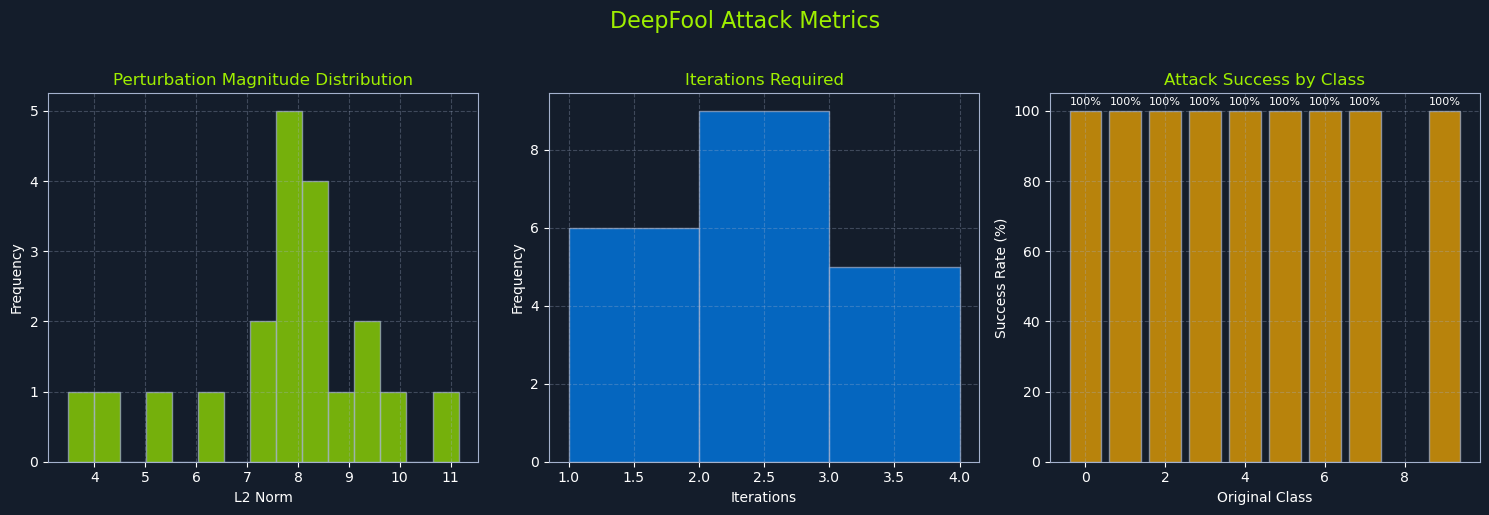

Metrics visualization saved to output/deepfool_metrics.png


In [33]:
print("\nGenerating attack metrics visualization...")


# Setup three-panel figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(NODE_BLACK)

for ax in axes:
    ax.set_facecolor(NODE_BLACK)
    for spine in ax.spines.values():
        spine.set_edgecolor(HACKER_GREY)
    ax.tick_params(colors=WHITE)
    ax.grid(True, alpha=0.3, color=HACKER_GREY, linestyle='--')

# Panel 1: L2 Norm Distribution
l2_norms = [r['l2_norm'] for r in results]
axes[0].hist(l2_norms, bins=15, color=HTB_GREEN, alpha=0.7, edgecolor=HACKER_GREY)
axes[0].set_xlabel('L2 Norm', color=WHITE)
axes[0].set_ylabel('Frequency', color=WHITE)
axes[0].set_title('Perturbation Magnitude Distribution', color=HTB_GREEN)
print(f"L2 norm range: [{min(l2_norms):.4f}, {max(l2_norms):.4f}]")

# Panel 2: Iteration Count Distribution
iterations = [r['iterations'] for r in results]
axes[1].hist(iterations, bins=range(1, max(iterations)+2),
            color=AZURE, alpha=0.7, edgecolor=HACKER_GREY)
axes[1].set_xlabel('Iterations', color=WHITE)
axes[1].set_ylabel('Frequency', color=WHITE)
axes[1].set_title('Iterations Required', color=HTB_GREEN)
print(f"Iteration range: [{min(iterations)}, {max(iterations)}]")

# Panel 3: Per-Class Success Rates
class_success = {}
for r in results:
    orig = r['original_label']
    if orig not in class_success:
        class_success[orig] = {'total': 0, 'success': 0}
    class_success[orig]['total'] += 1
    if r['success']:
        class_success[orig]['success'] += 1

classes = sorted(class_success.keys())
success_rates = [
    class_success[c]['success'] / class_success[c]['total'] * 100
    if class_success[c]['total'] > 0 else 0
    for c in classes
]

bars = axes[2].bar(classes, success_rates, color=NUGGET_YELLOW,
                   alpha=0.7, edgecolor=HACKER_GREY)
axes[2].set_xlabel('Original Class', color=WHITE)
axes[2].set_ylabel('Success Rate (%)', color=WHITE)
axes[2].set_title('Attack Success by Class', color=HTB_GREEN)
axes[2].set_ylim(0, 105)

# Add percentage labels on bars
for bar, rate in zip(bars, success_rates):
    height = bar.get_height()
    ax_x = bar.get_x() + bar.get_width() / 2.0
    axes[2].text(ax_x, height + 1, f'{rate:.0f}%',
                 ha='center', va='bottom', color=WHITE, fontsize=8)

# Save visualization
plt.suptitle('DeepFool Attack Metrics', color=HTB_GREEN, fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('output/deepfool_metrics.png',
            facecolor=NODE_BLACK, dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print("Metrics visualization saved to output/deepfool_metrics.png")

In [34]:
def print_summary_statistics(results):
    """
    Print summary statistics for attack results.

    Computes and displays success rate, perturbation statistics, iteration
    statistics, and common class transitions.

    Args:
        results (list): Attack results
    """
    print("\n" + "="*60)
    print("Attack Summary Statistics")
    print("="*60)

    successful_attacks = [r for r in results if r['success']]

    if successful_attacks:
        avg_l2 = np.mean([r['l2_norm'] for r in successful_attacks])
        avg_iterations = np.mean([r['iterations'] for r in successful_attacks])
        min_l2 = min([r['l2_norm'] for r in successful_attacks])
        max_l2 = max([r['l2_norm'] for r in successful_attacks])

        print(f"Success Rate: {len(successful_attacks)}/{len(results)} "
              f"({100*len(successful_attacks)/len(results):.1f}%)")
        print(f"Average L2 Norm: {avg_l2:.4f}")
        print(f"L2 Range: [{min_l2:.4f}, {max_l2:.4f}]")
        print(f"Average Iterations: {avg_iterations:.1f}")

        # Class transition analysis
        transitions = {}
        for r in successful_attacks:
            key = f"{r['original_label']}→{r['adversarial_label']}"
            transitions[key] = transitions.get(key, 0) + 1

        print(f"\nMost Common Misclassifications:")
        for trans, count in sorted(transitions.items(), key=lambda x: x[1], reverse=True)[:5]:
            print(f"  {trans}: {count} times")
    else:
        print("No successful attacks generated")

    print("="*60)

# Generate summary
print_summary_statistics(results)


Attack Summary Statistics
Success Rate: 20/20 (100.0%)
Average L2 Norm: 7.8228
L2 Range: [3.4764, 11.1569]
Average Iterations: 1.9

Most Common Misclassifications:
  1→8: 2 times
  9→4: 2 times
  9→8: 2 times
  7→3: 1 times
  2→6: 1 times
